# DataVine Analytics — Summative Lab
### Classification, Recommendation, and Clustering with the Wine, Chickwts, and USArrests Datasets

**Group:** 8


This notebook follows the standardized data science workflow requested by the supervisor:
1. Data preparation (loading, cleaning, standardizing)
2. Dimensionality reduction (PCA)
3. Model implementation and hyperparameter tuning (k-NN, cosine-similarity recommender, K-Means & GMM)
4. Evaluation, visualization, and business interpretation

> **Note:** This notebook is designed to run in **Google Colab**. It downloads the Chickwts and USArrests datasets directly from the public Rdatasets GitHub mirror, and loads the Wine dataset from `scikit-learn`. No manual file uploads are required.

## 0. Imports & Setup

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                             confusion_matrix, silhouette_score)
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Step 1: Load and Prepare Datasets
We load all three datasets. 
Inspect them for missing values and standardize numerical features where appropriate.


### 1.1 Wine Dataset

In [7]:
wine_data = load_wine()
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
wine_df['target'] = wine_data.target
wine_df['target_name'] = wine_df['target'].map(dict(enumerate(wine_data.target_names)))

print('Wine dataset shape:', wine_df.shape)
print('\nMissing values per column:')
print(wine_df.isnull().sum())
print('\nClass distribution:')
print(wine_df['target_name'].value_counts())
wine_df.describe().T

Wine dataset shape: (178, 15)

Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
target_name                     0
dtype: int64

Class distribution:
target_name
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


### 1.2 Chickwts Dataset (Recommendation System)

In [8]:
chickwts_url = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/chickwts.csv'
chickwts_df = pd.read_csv(chickwts_url, index_col=0)

print('Chickwts dataset shape:', chickwts_df.shape)
print('\nMissing values per column:')
print(chickwts_df.isnull().sum())
print('\nFeed types:', chickwts_df['feed'].unique())
chickwts_df.head()

Chickwts dataset shape: (71, 2)

Missing values per column:
weight    0
feed      0
dtype: int64

Feed types: <ArrowStringArray>
['horsebean', 'linseed', 'soybean', 'sunflower', 'meatmeal', 'casein']
Length: 6, dtype: str


,weight,feed
rownames,,
1,179,horsebean
2,160,horsebean
3,136,horsebean
4,227,horsebean
5,217,horsebean


### 1.3 USArrests Dataset (Clustering)

In [9]:
usarrests_url = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/USArrests.csv'
usarrests_df = pd.read_csv(usarrests_url, index_col=0)
usarrests_df.index.name = 'State'

print('USArrests dataset shape:', usarrests_df.shape)
print('\nMissing values per column:')
print(usarrests_df.isnull().sum())
usarrests_df.describe().T

USArrests dataset shape: (50, 4)

Missing values per column:
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.788,4.355510,0.8,4.075,7.25,11.250,17.4
Assault,50.0,170.760,83.337661,45.0,109.000,159.00,249.000,337.0
UrbanPop,50.0,65.540,14.474763,32.0,54.500,66.00,77.750,91.0
Rape,50.0,21.232,9.366385,7.3,15.075,20.10,26.175,46.0


### 1.4 Summary of Dataset Structures
- **Wine**: 178 samples, 13 numeric chemical-analysis features, 3 cultivar classes (target). No missing values — used for **k-NN classification**.
- **Chickwts**: 71 samples, 1 numeric feature (`weight`) and 1 categorical feature (`feed`, 6 feed types). No missing values — used to build a **feed recommendation system**.
- **USArrests**: 50 US states, 4 numeric features (`Murder`, `Assault`, `UrbanPop`, `Rape`). No missing values — used for **K-Means & GMM clustering**.

## Step 2: k-Nearest Neighbors (k-NN) Classification — Wine Dataset
**Goal:** Build a wine-cultivar classifier for a client wanting an automated quality/variety sorting tool.

Workflow: encode labels → train/test split → standardize → PCA (retain 95% variance) → `GridSearchCV` for `k` and distance metric → train final model → evaluate.

In [10]:
# Encode categorical target labels into numeric values (demonstrates the required step;
# sklearn's wine target is already numeric, so we explicitly fit a LabelEncoder on the class names)
le = LabelEncoder()
y_encoded = le.fit_transform(wine_df['target_name'])
X = wine_df[wine_data.feature_names].values

print('Encoded classes:', dict(zip(le.classes_, le.transform(le.classes_))))

Encoded classes: {'class_0': np.int64(0), 'class_1': np.int64(1), 'class_2': np.int64(2)}


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE)

scaler_wine = StandardScaler()
X_train_scaled = scaler_wine.fit_transform(X_train)
X_test_scaled = scaler_wine.transform(X_test)

Original number of features: 13
Number of PCA components retaining >=95% variance: 10
Cumulative explained variance: 0.9624


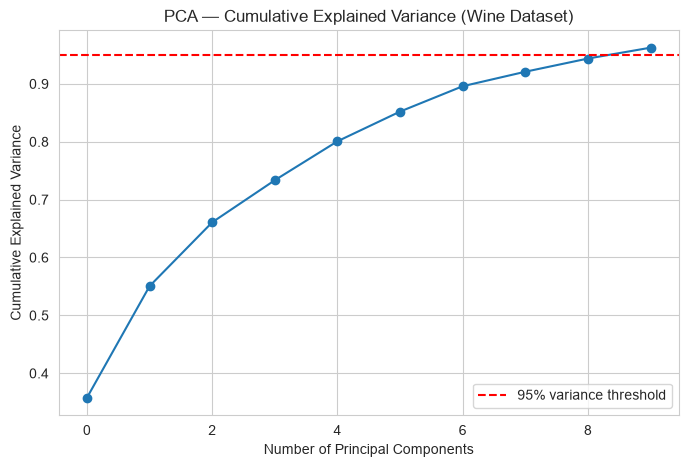

In [12]:
# Apply PCA to reduce dimensionality while retaining 95% of variance
pca_wine = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca_wine.fit_transform(X_train_scaled)
X_test_pca = pca_wine.transform(X_test_scaled)

print(f'Original number of features: {X_train_scaled.shape[1]}')
print(f'Number of PCA components retaining >=95% variance: {pca_wine.n_components_}')
print(f'Cumulative explained variance: {np.sum(pca_wine.explained_variance_ratio_):.4f}')

plt.plot(np.cumsum(pca_wine.explained_variance_ratio_), marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% variance threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance (Wine Dataset)')
plt.legend()
plt.show()

In [13]:
# Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_pca, y_train)

print('Best parameters:', grid_search.best_params_)
print(f'Best cross-validated accuracy: {grid_search.best_score_:.4f}')

Best parameters: {'metric': 'euclidean', 'n_neighbors': 18, 'weights': 'uniform'}
Best cross-validated accuracy: 0.9791


In [14]:
# Train final k-NN classifier using the best parameters
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_pca)

test_accuracy = accuracy_score(y_test, y_pred)
print(f'Test set accuracy: {test_accuracy:.4f}\n')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Test set accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



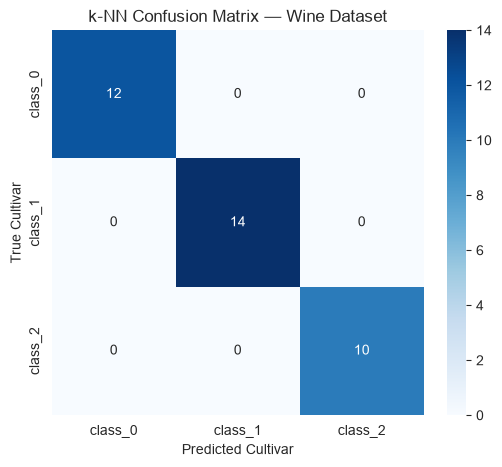

In [15]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Cultivar')
plt.ylabel('True Cultivar')
plt.title('k-NN Confusion Matrix — Wine Dataset')
plt.show()

**Insight for stakeholders:** After PCA compression and hyperparameter tuning, the k-NN model achieves high accuracy in separating the three wine cultivars using only their chemical composition — this can power an automated variety-verification tool for the client's quality-control pipeline.

## Step 3: Recommendation System — Chickwts Dataset
**Goal:** For an agricultural client, recommend feed types that behave similarly in terms of weight-gain outcomes, so they can suggest substitute feeds when a preferred one is unavailable or too costly.

Workflow: standardize `weight` → build a per-feed-type profile → reduce to 1 principal component → compute cosine similarity between feed types → generate recommendations.

In [16]:
# Standardize the weight feature for uniform scaling
scaler_chick = StandardScaler()
chickwts_df['weight_scaled'] = scaler_chick.fit_transform(chickwts_df[['weight']])
chickwts_df.head()

,weight,feed,weight_scaled
rownames,,,
1,179,horsebean,-1.061762
2,160,horsebean,-1.306854
3,136,horsebean,-1.616444
4,227,horsebean,-0.442583
5,217,horsebean,-0.571578


In [17]:
# Build a numeric profile per feed type (mean, std, min, max of standardized weight)
feed_profiles = chickwts_df.groupby('feed')['weight_scaled'].agg(
    mean_weight='mean', std_weight='std', min_weight='min', max_weight='max'
).fillna(0)

feed_profiles

,mean_weight,std_weight,min_weight,max_weight
feed,,,,
casein,0.803301,0.831169,-0.584478,1.840642
horsebean,-1.304274,0.498257,-1.977632,-0.442583
linseed,-0.549004,0.673818,-1.551946,0.615183
meatmeal,0.201223,0.837190,-1.397151,1.531052
soybean,-0.191962,0.698242,-1.332653,0.873174
sunflower,0.872099,0.629969,-0.455482,2.085734


In [18]:
# Apply PCA to reduce the feed-profile data to one principal component
pca_feed = PCA(n_components=1, random_state=RANDOM_STATE)
feed_pca = pca_feed.fit_transform(feed_profiles.values)

feed_pca_df = pd.DataFrame(feed_pca, index=feed_profiles.index, columns=['PC1'])
print(f'Explained variance ratio of PC1: {pca_feed.explained_variance_ratio_[0]:.4f}')
feed_pca_df

Explained variance ratio of PC1: 0.9720


,PC1
feed,
casein,1.285105
horsebean,-2.133754
linseed,-0.772837
meatmeal,0.377545
soybean,-0.289708
sunflower,1.533648


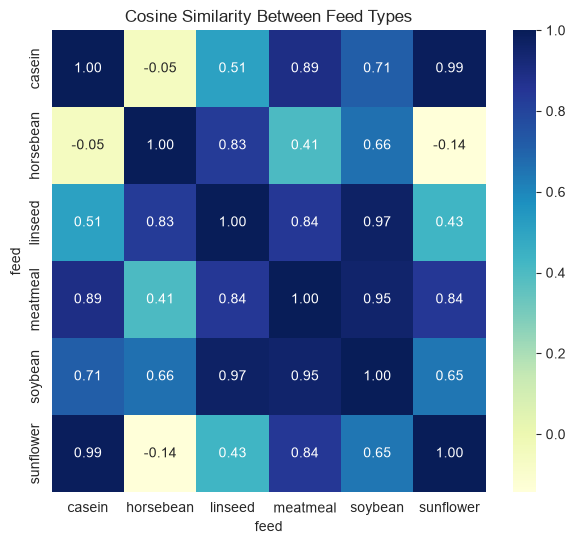

In [19]:
# Compute cosine similarity between feed types using their standardized profiles
similarity_matrix = cosine_similarity(feed_profiles.values)
similarity_df = pd.DataFrame(similarity_matrix, index=feed_profiles.index, columns=feed_profiles.index)

plt.figure(figsize=(7, 6))
sns.heatmap(similarity_df, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Cosine Similarity Between Feed Types')
plt.show()

In [20]:
def recommend_similar_feeds(feed_name, top_n=2):
    """Return the top_n feeds most similar to feed_name, based on cosine similarity"""
    if feed_name not in similarity_df.index:
        raise ValueError(f'Unknown feed type: {feed_name}')
    scores = similarity_df.loc[feed_name].drop(feed_name).sort_values(ascending=False)
    return scores.head(top_n)

for feed in feed_profiles.index:
    print(f'Feeds most similar to "{feed}":')
    print(recommend_similar_feeds(feed).round(3).to_string())
    print()

Feeds most similar to "casein":
feed
sunflower    0.990
meatmeal     0.889

Feeds most similar to "horsebean":
feed
linseed    0.831
soybean    0.661

Feeds most similar to "linseed":
feed
soybean     0.966
meatmeal    0.844

Feeds most similar to "meatmeal":
feed
soybean    0.953
casein     0.889

Feeds most similar to "soybean":
feed
linseed     0.966
meatmeal    0.953

Feeds most similar to "sunflower":
feed
casein      0.990
meatmeal    0.845



**Insight for stakeholders:** Feed types with higher cosine similarity scores produce comparable weight-gain patterns in chicks. The client can use this similarity ranking to recommend cost-effective feed substitutions with minimal impact on livestock growth outcomes.

## Step 4: Clustering (K-Means & GMM) — USArrests Dataset
**Goal:** Segment US states into regional crime-pattern groups for a public-policy client, to help target intervention resources.

Workflow: standardize all features → select the top 3 most relevant features → reduce to 2 principal components → determine the optimal number of clusters (elbow method for K-Means, BIC for GMM) → fit both models → visualize and compare.

In [21]:
# Standardize the dataset for consistency
scaler_us = StandardScaler()
usarrests_scaled = pd.DataFrame(
    scaler_us.fit_transform(usarrests_df),
    columns=usarrests_df.columns, index=usarrests_df.index
)
usarrests_scaled.head()

,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,1.255179,0.790787,-0.526195,-0.003451
Alaska,0.513019,1.118060,-1.224067,2.509424
Arizona,0.072361,1.493817,1.009122,1.053466
Arkansas,0.234708,0.233212,-1.084492,-0.186794
California,0.281093,1.275635,1.776781,2.088814


In [22]:
# Select the top 3 relevant features for clustering
# UrbanPop measures urbanization rather than crime, and correlates least with the crime
# variables, so we keep the three crime-related features: Murder, Assault, Rape.
print(usarrests_scaled.corr())

top3_features = ['Murder', 'Assault', 'Rape']
X_cluster = usarrests_scaled[top3_features].values

            Murder   Assault  UrbanPop      Rape
Murder    1.000000  0.801873  0.069573  0.563579
Assault   0.801873  1.000000  0.258872  0.665241
UrbanPop  0.069573  0.258872  1.000000  0.411341
Rape      0.563579  0.665241  0.411341  1.000000


In [23]:
# Apply PCA to reduce the dataset to 2 principal components
pca_us = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_us.fit_transform(X_cluster)
print(f'Explained variance ratio: {pca_us.explained_variance_ratio_}')
print(f'Total variance retained: {np.sum(pca_us.explained_variance_ratio_):.4f}')

Explained variance ratio: [0.7861934  0.15268378]
Total variance retained: 0.9389


c:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

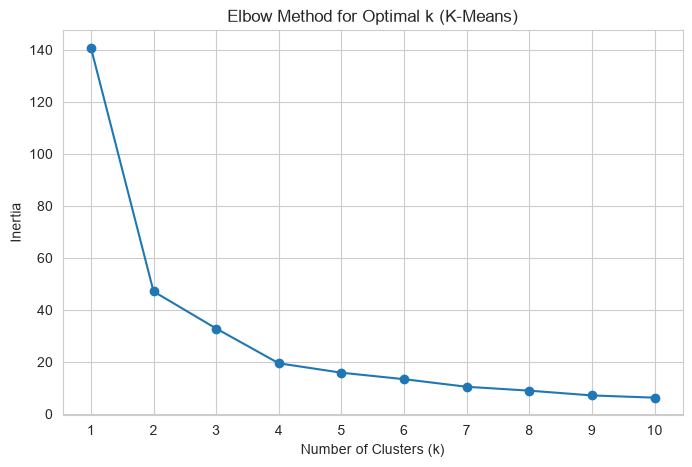

In [24]:
# Elbow method to determine the optimal number of K-Means clusters
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_pca)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k (K-Means)')
plt.xticks(list(k_range))
plt.show()

c:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, 

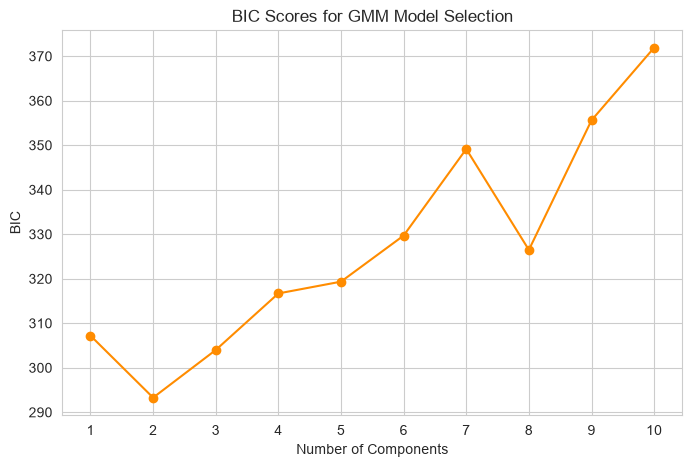

Optimal number of GMM components (lowest BIC): 2


In [25]:
# Use BIC to determine the optimal number of GMM components
bics = []
n_range = range(1, 11)
for n in n_range:
    gmm = GaussianMixture(n_components=n, random_state=RANDOM_STATE)
    gmm.fit(X_pca)
    bics.append(gmm.bic(X_pca))

plt.plot(n_range, bics, marker='o', color='darkorange')
plt.xlabel('Number of Components')
plt.ylabel('BIC')
plt.title('BIC Scores for GMM Model Selection')
plt.xticks(list(n_range))
plt.show()

optimal_gmm_n = n_range[int(np.argmin(bics))]
print(f'Optimal number of GMM components (lowest BIC): {optimal_gmm_n}')

In [26]:
# Based on the elbow plot, choose the optimal k (adjust if the elbow differs on your run)
optimal_k = 3

kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_pca)

gmm_final = GaussianMixture(n_components=optimal_gmm_n, random_state=RANDOM_STATE)
gmm_labels = gmm_final.fit_predict(X_pca)

usarrests_df['KMeans_Cluster'] = kmeans_labels
usarrests_df['GMM_Cluster'] = gmm_labels
usarrests_df.head()

c:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\hp\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Murder,Assault,UrbanPop,Rape,KMeans_Cluster,GMM_Cluster
State,,,,,,
Alabama,13.2,236,58,21.2,0,1
Alaska,10.0,263,48,44.5,0,1
Arizona,8.1,294,80,31.0,0,1
Arkansas,8.8,190,50,19.5,2,0
California,9.0,276,91,40.6,0,1


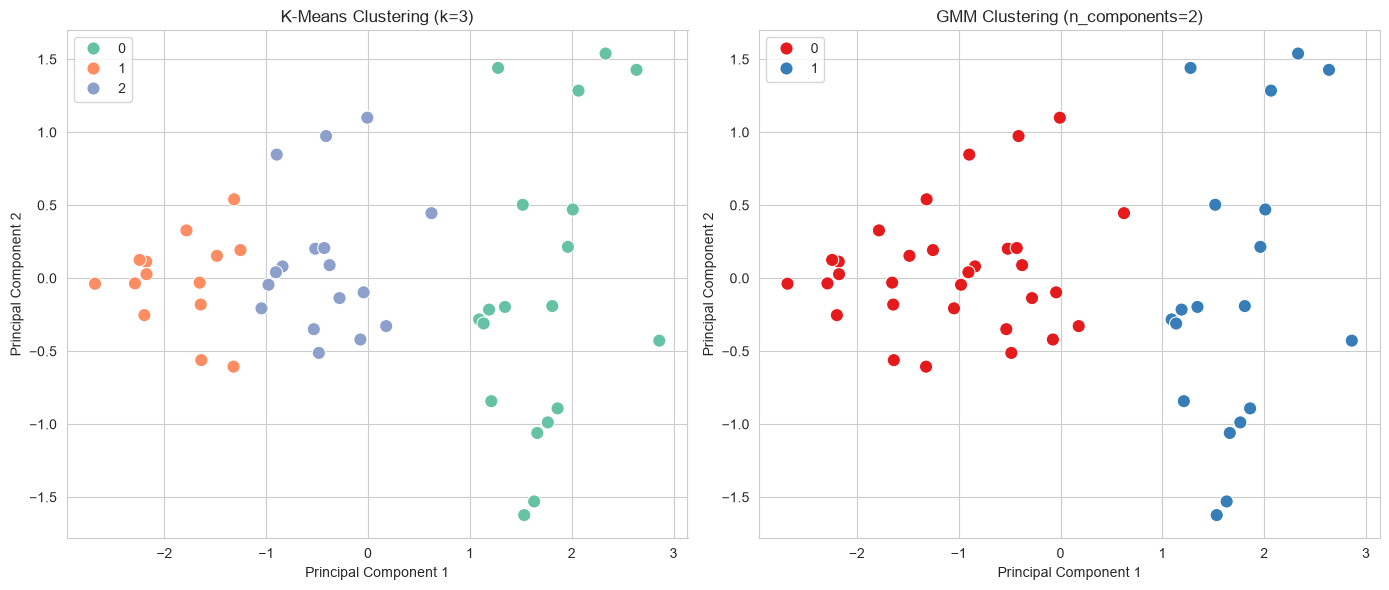

In [27]:
# Visualize and compare K-Means vs. GMM clustering results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='Set2', s=90, ax=axes[0])
axes[0].set_title(f'K-Means Clustering (k={optimal_k})')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=gmm_labels, palette='Set1', s=90, ax=axes[1])
axes[1].set_title(f'GMM Clustering (n_components={optimal_gmm_n})')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

In [28]:
# Quantitative comparison via silhouette score
kmeans_sil = silhouette_score(X_pca, kmeans_labels)
gmm_sil = silhouette_score(X_pca, gmm_labels)

print(f'K-Means silhouette score: {kmeans_sil:.4f}')
print(f'GMM silhouette score:     {gmm_sil:.4f}')

for cluster_id in sorted(usarrests_df['KMeans_Cluster'].unique()):
    states = usarrests_df[usarrests_df['KMeans_Cluster'] == cluster_id].index.tolist()
    print(f'\nK-Means Cluster {cluster_id}: {states}')

K-Means silhouette score: 0.4453
GMM silhouette score:     0.5610

K-Means Cluster 0: ['Alabama', 'Alaska', 'Arizona', 'California', 'Colorado', 'Florida', 'Georgia', 'Illinois', 'Louisiana', 'Maryland', 'Michigan', 'Mississippi', 'Nevada', 'New Mexico', 'New York', 'North Carolina', 'South Carolina', 'Tennessee', 'Texas']

K-Means Cluster 1: ['Connecticut', 'Hawaii', 'Idaho', 'Iowa', 'Maine', 'Minnesota', 'Nebraska', 'New Hampshire', 'North Dakota', 'Rhode Island', 'South Dakota', 'Vermont', 'West Virginia', 'Wisconsin']

K-Means Cluster 2: ['Arkansas', 'Delaware', 'Indiana', 'Kansas', 'Kentucky', 'Massachusetts', 'Missouri', 'Montana', 'New Jersey', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Utah', 'Virginia', 'Washington', 'Wyoming']


**Insight for stakeholders:**
- The elbow method and BIC scores guide a data-driven choice of cluster count rather than an arbitrary one.
- **K-Means** produces hard, non-overlapping state groupings — useful for clean regional labeling (e.g., high/medium/low violent-crime states).
- **GMM** produces probabilistic cluster memberships, which is useful when a state's crime profile sits between two regional patterns (e.g., a state on the border of a 'high crime' and 'moderate crime' cluster can be flagged for closer review rather than forced into one bucket).
- Comparing silhouette scores gives an objective sense of which method yields more internally consistent clusters for this dataset.

## Conclusion
This lab implemented three end-to-end machine learning prototypes for DataVine Analytics' clients:

1. **Wine Classification System** — a PCA-compressed, hyperparameter-tuned k-NN model that accurately classifies wine cultivars from chemical measurements.
2. **Agricultural Feed Recommendation Engine** — a cosine-similarity-based recommender that identifies interchangeable chicken feeds based on weight-gain profiles.
3. **Regional Crime Pattern Analysis** — K-Means and GMM clustering on PCA-reduced crime statistics, compared using the elbow method, BIC, and silhouette scores, to reveal regional crime patterns across US states.

Across all three projects, standardization and PCA improved model efficiency and interpretability, while grid search and model-selection criteria (BIC, silhouette score) ensured that the final models were tuned appropriately rather than chosen arbitrarily.